In [1]:
import numpy as np

import os

from nbodykit.lab import *
from nbodykit import setup_logging, style

import matplotlib.pyplot as plt

from baryonification.baryonification.params import par

par = par()

if par.code.multicomp:
    comp = 'multicomp' #'multicomp' or 'singlecomp'
else:
    comp = 'singlecomp'

size = par.code.size #'big' or 'small'

Found 2097152 particles


In [2]:
gas_hist = np.load('results_{}_{}/gas_pp.npy'.format(comp, size))
dm_hist = np.load('results_{}_{}/dm_pp.npy'.format(comp, size))
gas_hist_Osato = np.load('results_{}_{}/gas_hp.npy'.format(comp, size))
dm_hist_Osato = np.load('results_{}_{}/dm_hp.npy'.format(comp, size))

if size=='small':
    bins = 500
elif size=='big':
    bins = 1000

In [3]:
#I follow this tutorial for fourier transform: https://bertvandenbroucke.netlify.app/2019/05/24/computing-a-power-spectrum-in-python/

gas_fourier = np.fft.fftn(gas_hist)
dm_fourier = np.fft.fftn(dm_hist)
gas_fourier_Osato = np.fft.fftn(gas_hist_Osato)
dm_fourier_Osato = np.fft.fftn(dm_hist_Osato)

In [4]:
gas_amplitudes = np.abs(gas_fourier)**2
dm_amplitudes = np.abs(dm_fourier)**2
gas_amplitudes_Osato = np.abs(gas_fourier_Osato)**2
dm_amplitudes_Osato = np.abs(dm_fourier_Osato)**2

In [5]:
kfreq = np.fft.fftfreq(bins) * bins
kfreq2D = np.meshgrid(kfreq, kfreq)
knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)

In [6]:
knrm = knrm.flatten()
gas_amplitudes = gas_amplitudes.flatten()
dm_amplitudes = dm_amplitudes.flatten()
gas_amplitudes_Osato = gas_amplitudes_Osato.flatten()
dm_amplitudes_Osato = dm_amplitudes_Osato.flatten()

kbins = np.arange(0.5, bins//2+1, 1.)
kvals = 0.5 * (kbins[1:] + kbins[:-1])

In [7]:
import scipy.stats as stats

gas_Abins, _, _ = stats.binned_statistic(knrm, gas_amplitudes,
                                     statistic = "mean",
                                     bins = kbins)

dm_Abins, _, _ = stats.binned_statistic(knrm, dm_amplitudes,
                                     statistic = "mean",
                                     bins = kbins)

gas_Abins_Osato, _, _ = stats.binned_statistic(knrm, gas_amplitudes_Osato,
                                     statistic = "mean",
                                     bins = kbins)

dm_Abins_Osato, _, _ = stats.binned_statistic(knrm, dm_amplitudes_Osato,
                                     statistic = "mean",
                                     bins = kbins)

In [8]:
gas_Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)

dm_Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)

gas_Abins_Osato *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)

dm_Abins_Osato *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)

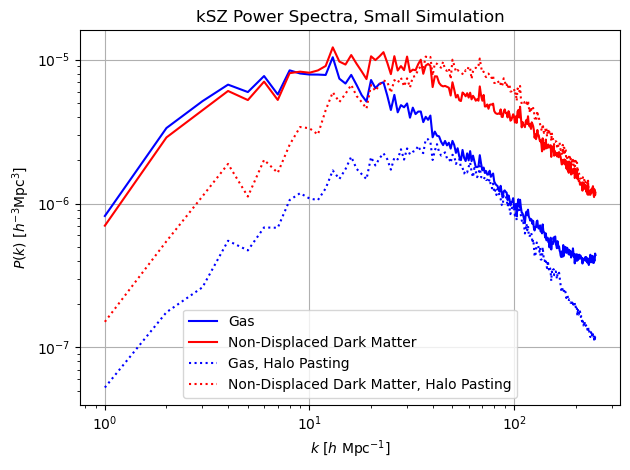

In [15]:
plt.loglog(kvals, gas_Abins, color='blue', label='Gas')
plt.loglog(kvals, dm_Abins, color='red', label='Non-Displaced Dark Matter')
plt.loglog(kvals, gas_Abins_Osato, color='blue', label='Gas, Halo Pasting', linestyle='dotted')
plt.loglog(kvals, dm_Abins_Osato, color='red', label='Non-Displaced Dark Matter, Halo Pasting', linestyle='dotted')
plt.xlabel(r"$k$ [$h \ \mathrm{Mpc}^{-1}$]")
plt.ylabel(r"$P(k)$ [$h^{-3}\mathrm{Mpc}^3$]")
if size=='small':
    plt.title("kSZ Power Spectra, Small Simulation")
elif size=='big':
    plt.title("kSZ Power Spectra, Large Simulation")
plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig(os.path.join('{}_{}'.format(comp, size), 'SZPowerSpectra.pdf'), bbox_inches='tight')

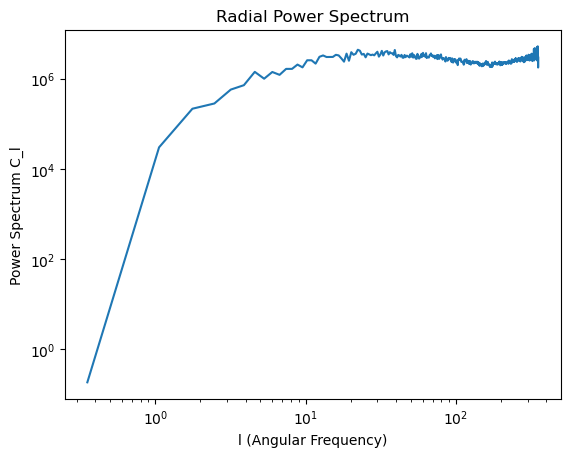

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming `histogram` is your 2D histogram or image
histogram = gas_hist  # Replace this with your actual histogram

# Step 1: Compute the 2D Fourier Transform of the histogram
f_transform = np.fft.fftshift(np.fft.fft2(histogram))

# Step 2: Compute the power spectrum (squared magnitude of Fourier transform)
power_spectrum = np.abs(f_transform) ** 2

# Step 3: Compute the radial distances (in Fourier space)
# Define the center of the Fourier transform
center = np.array(histogram.shape) // 2
y, x = np.indices(histogram.shape)
r = np.sqrt((x - center[1])**2 + (y - center[0])**2)

# Step 4: Bin the power spectrum radially
# Binning into angular bins
num_bins = 500  # Number of bins for radial averaging
max_radius = np.max(r)
bin_edges = np.linspace(0, max_radius, num_bins+1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Compute the radial averaged power spectrum (C_l-like)
radial_power_spectrum = np.zeros(num_bins)
for i in range(num_bins):
    mask = (r >= bin_edges[i]) & (r < bin_edges[i+1])
    radial_power_spectrum[i] = np.mean(power_spectrum[mask])

# Step 5: Plot the radial power spectrum
plt.figure()
plt.loglog(bin_centers, (10.0**12.0) * radial_power_spectrum*bin_centers*(bin_centers+1.0)/(2*np.pi))
plt.xlabel('l (Angular Frequency)')
plt.ylabel('Power Spectrum C_l')
plt.title('Radial Power Spectrum')
plt.show()

In [12]:
def calculate_angular_power_spectrum(image):
    """
    Calculates the angular power spectrum of a 2D array.

    Args:
        image (numpy.ndarray): A 2D numpy array representing the image.

    Returns:
        tuple: A tuple containing:
            - k_radii (numpy.ndarray): Radial wavenumbers (k) values.
            - power_spectrum_1d (numpy.ndarray): 1D power spectrum.
    """
    # 1. Fourier Transform
    fft_image = np.fft.fft2(image)
    fft_shifted = np.fft.fftshift(fft_image)

    # 2. Calculate Power Spectrum
    power_spectrum_2d = np.abs(fft_shifted)**2

    # 3. Radial Averaging
    ny, nx = image.shape
    cy, cx = ny // 2, nx // 2

    # Create an array of distances from the center
    y, x = np.indices((ny, nx))
    r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)

    # Accumulate power values for each radius
    radial_sum = np.bincount(r.ravel(), power_spectrum_2d.ravel())
    radial_count = np.bincount(r.ravel())

    # Avoid division by zero
    radial_count[radial_count == 0] = 1

    # Average power at each radius
    power_spectrum_1d = radial_sum / radial_count

    # 4. Wavenumber Radii
    k_radii = np.arange(len(power_spectrum_1d))

    return k_radii, power_spectrum_1d

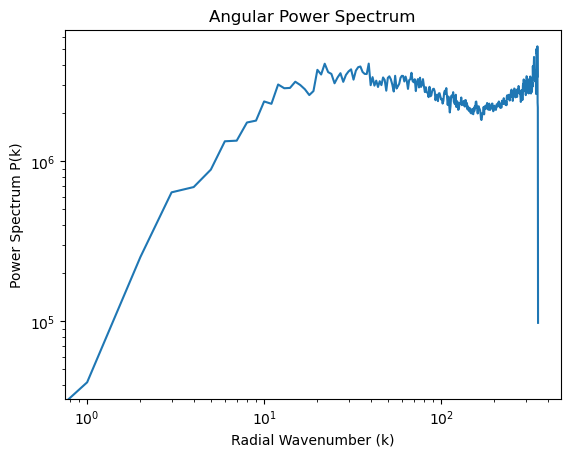

In [13]:
k_radii, power_spectrum = calculate_angular_power_spectrum(gas_hist)

# Plotting the power spectrum (optional, requires matplotlib)
plt.plot(k_radii, 10.0**12.0 * k_radii*(k_radii + 1.0)*power_spectrum/(2 * np.pi))
plt.xlabel("Radial Wavenumber (k)")
plt.ylabel("Power Spectrum P(k)")
plt.title("Angular Power Spectrum")
plt.yscale('log')  # Use log scale for better visualization
plt.xscale('log')
plt.show()